<h2>Data Analytics - Stroke Prediction Dataset</h2>

<h4><b>Short description:</b></h4>

Stroke Prediction Dataset - healthcare data used to identify key risk factors associated with stroke events in patients.


<h4><b>Data source (url):</b></h4>

(https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)


<h4><b>Data format:</b></h4>

Single CSV file.


<h4><b>Data description, features and limitations:</b></h4>

The dataset contains 5,110 patient records with 12 columns covering demographic, lifestyle and medical attributes used to predict stroke occurrence.

**Columns:**
- id - unique patient identifier (not used in analysis)
- gender - Male, Female or Other
- age - patient age in years
- hypertension - 1 if the patient has hypertension. 0 otherwise
- heart_disease - 1 if the patient has heart disease. 0 otherwise
- ever_married - Yes / No
- work_type - Private, Self-employed, Govt_job, children, Never_worked
- Residence_type - Urban or Rural
- avg_glucose_level - average blood glucose level (mg/dL). range: 55.12 – 271.74
- bmi - body mass index, range: 10.3 – 97.6
- smoking_status - never smoked, formerly smoked, smokes or Unknown
- stroke - 1 if the patient had a stroke. 0 otherwise

**Limitations:**
- The dataset is heavily **imbalanced.** Only 4.7% of patients had a stroke (249 out of 5,110). This means that stroke cases are underrepresented. Which should be kept in mind when interpreting proportions and patterns.
- 201 rows (~3.9%) have missing BMI values. These rows were removed from the analysis, reducing the working dataset to 4,908 rows.
- 1 patient has gender listed as "Other" This removed as a statistical outlier with no analytical value.
- 1,544 patients have smoking_status listed as "Unknown", which limits conclusions about smoking as a risk factor.


<h3><b>Code: importing modules, custom functions and loading the data</b></h3>


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load the data
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

print(df.shape)
print(df.dtypes)
df.head(10)

(5110, 12)
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


<h3><b>Code: Data clean-up procedure</b></h3>


In [2]:
# the 'id' column is a unique identifier with no analytical value.
df = df.drop('id', axis=1)

# drop the 201 rows with missing BMI values
df = df.dropna(subset=['bmi'])

# there is exactly 1 patient with gender 'Other' - removed as a statistical outlier
df = df[df['gender'] != 'Other']

print(f"Working dataset: {len(df)} rows, {df.shape[1]} columns")
print(f"Stroke cases: {df['stroke'].sum()}")

Working dataset: 4908 rows, 11 columns
Stroke cases: 209


In [3]:
# create age groups for grouped analysis. groups are decade-sized
# which aligns with how age related risk is commonly discussed in medical literature
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 30, 40, 50, 60, 70, 82],
    labels=['0–18', '19–30', '31–40', '41–50', '51–60', '61–70', '71–82']
)

# verify no new nulls
print("Null values per column after cleanup:")
print(df.isnull().sum())

Null values per column after cleanup:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
age_group            0
dtype: int64


<h3><b>Code: Data analysis</b></h3>


#### 1. Distribution

Before exploring any relationships, it is important to visualise how imbalanced the target variable is.

C:\Users\savin\AppData\Local\Temp\ipykernel_73468\1513291352.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stroke_counts.index, y=stroke_counts.values, palette='Set2')


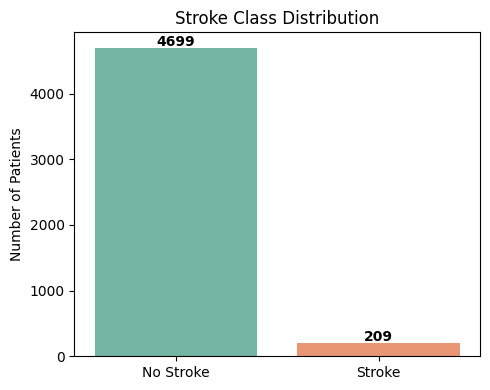

In [4]:
stroke_counts = df['stroke'].value_counts().rename({0: 'No Stroke', 1: 'Stroke'})

plt.figure(figsize=(5, 4))
sns.barplot(x=stroke_counts.index, y=stroke_counts.values, palette='Set2')
plt.title('Stroke Class Distribution')
plt.ylabel('Number of Patients')
plt.xlabel('')
for i, v in enumerate(stroke_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# The class imbalance is extreme - 4,697 non-stroke cases vs 211 stroke cases.
# This is important because even small absolute numbers among stroke patients
# can appear as large percentage differences in grouped comparisons.

#### 2. Correlation heatmap of numeric features

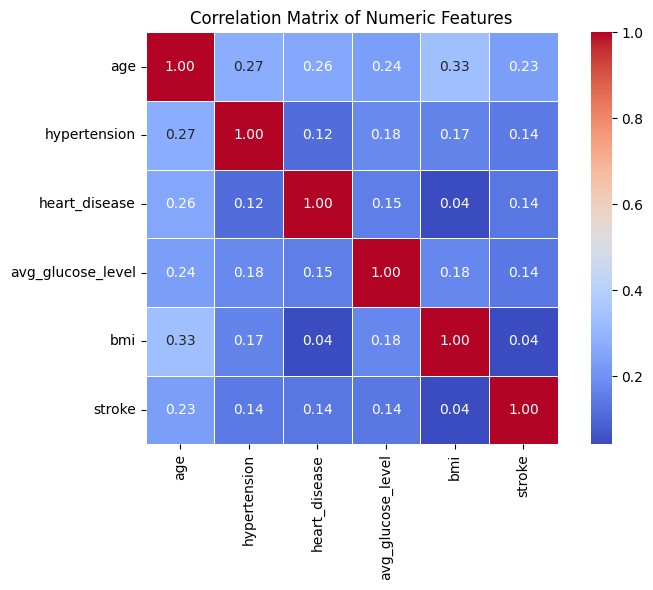

In [5]:
numeric_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
correlations = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# Age has the strongest positive correlation with stroke among all numeric features.
# Hypertension, average glucose level and heart disease also show moderate positive correlations.
# BMI show weaker but positive correlations with stroke.
# Notably, age also correlates with hypertension, average glucose level and heart disease
# suggesting that older patients in this dataset tend to have more strokes.

#### 3. Pairplot of numeric features

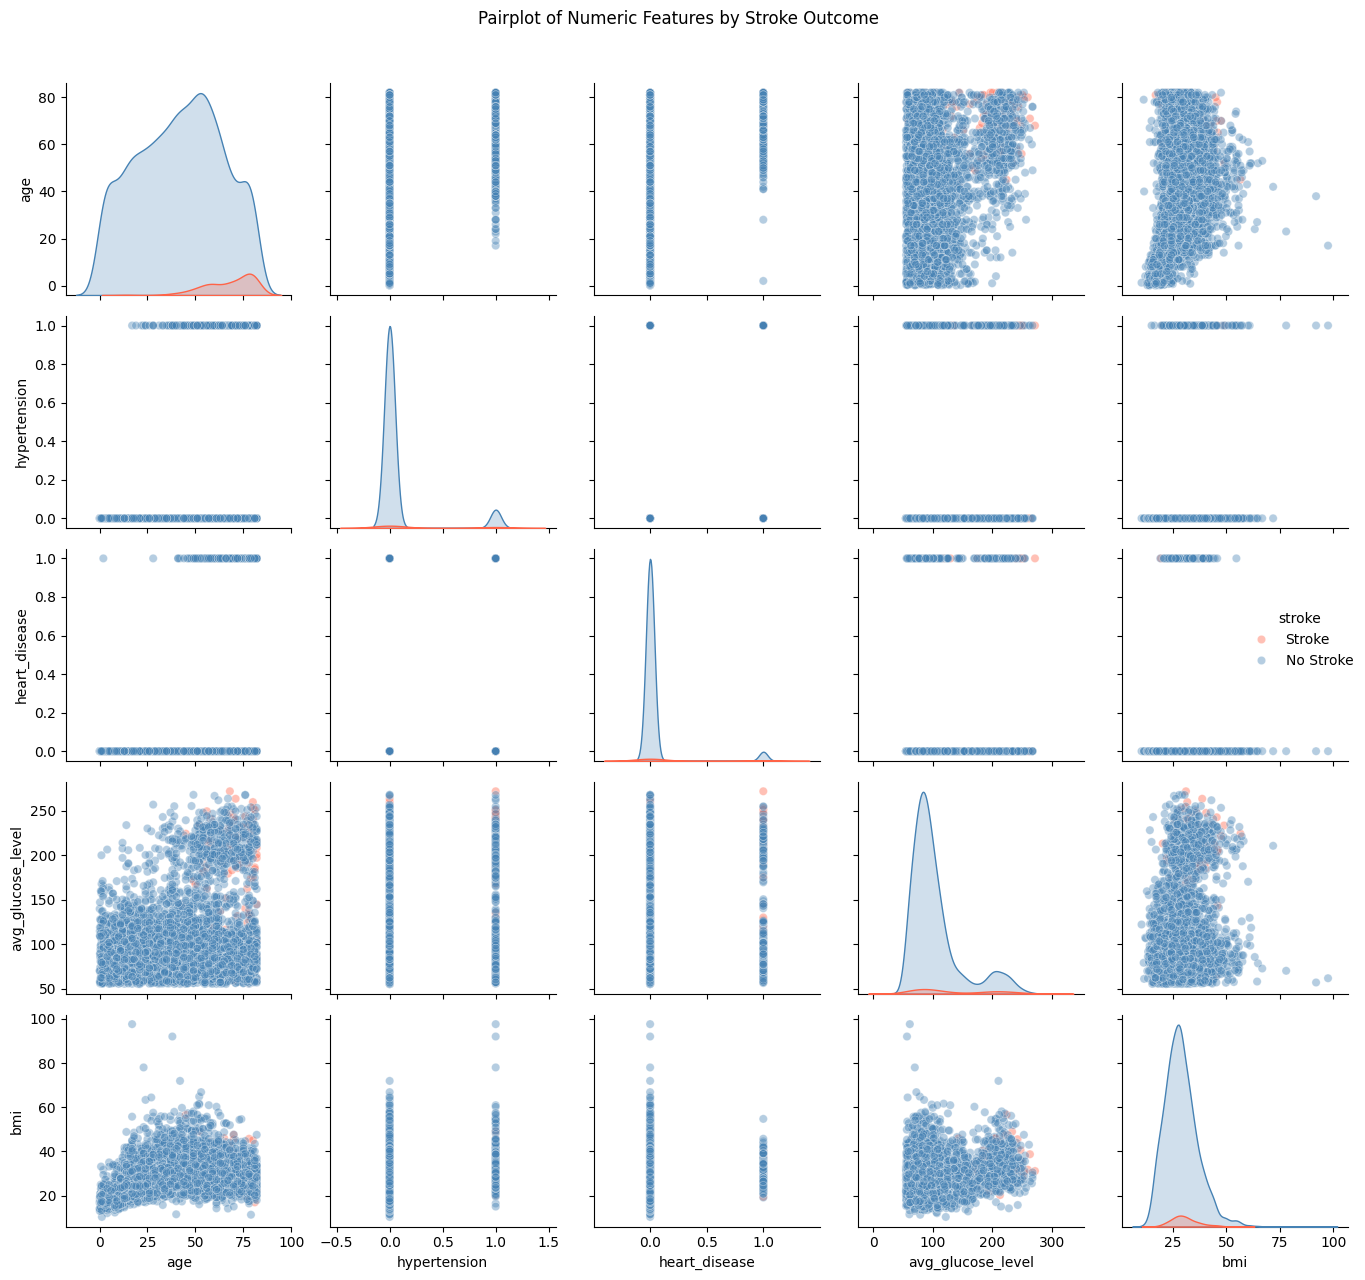

In [6]:
# pairplot coloured by stroke outcome
pairplot_df = df[numeric_cols].copy()
pairplot_df['stroke'] = pairplot_df['stroke'].map({0: 'No Stroke', 1: 'Stroke'})

sns.pairplot(pairplot_df, hue='stroke', palette={'No Stroke': 'steelblue', 'Stroke': 'tomato'}, plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Numeric Features by Stroke Outcome', y=1.02)
plt.tight_layout()
plt.show()

# The age distribution on the diagonal clearly shows that stroke patients tend
# to be concentrated in the older age range. the red distribution is shifted right.
# Glucose level also shows a slight right shift for stroke patients.
# BMI distributions largely overlap, suggesting it is a weaker individual predictor.

#### 4. Stroke rate by age group

Since age has the strongest correlation with stroke, it is worth looking at stroke rates per age group.

C:\Users\savin\AppData\Local\Temp\ipykernel_73468\2934654804.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stroke_by_age, x='age_group', y='stroke_pct', palette='Oranges')


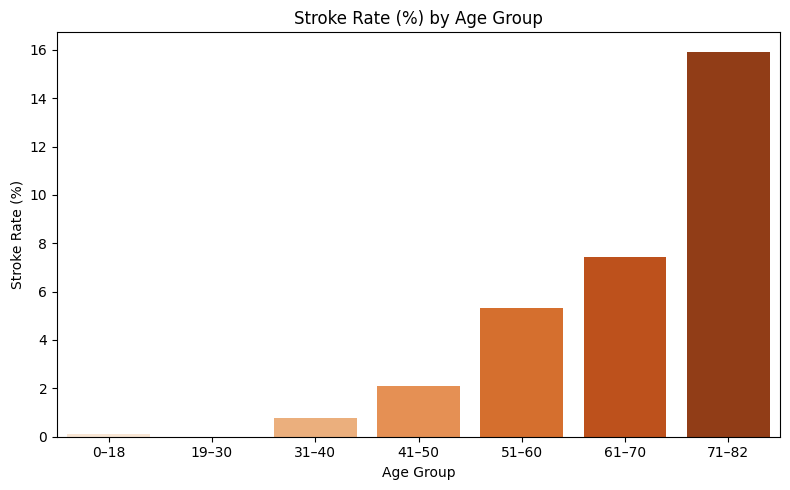

In [7]:
stroke_by_age = df.groupby('age_group', observed=True)['stroke'].mean().reset_index()
stroke_by_age['stroke_pct'] = stroke_by_age['stroke'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=stroke_by_age, x='age_group', y='stroke_pct', palette='Oranges')
plt.title('Stroke Rate (%) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Stroke Rate (%)')
plt.tight_layout()
plt.show()

# Patients aged 71–82 have around 16% stroke rate.
# compared to near zero for patients under 40.
# Stroke risk rises steeply after age 50, which aligns with
# well established medical knowledge about age as a primary stroke risk factor.

#### 5. Stroke rate by categorical features

C:\Users\savin\AppData\Local\Temp\ipykernel_73468\3543517394.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=column, y='stroke_pct', palette='Set2', ax=ax)
C:\Users\savin\AppData\Local\Temp\ipykernel_73468\3543517394.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=column, y='stroke_pct', palette='Set2', ax=ax)
C:\Users\savin\AppData\Local\Temp\ipykernel_73468\3543517394.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=column, y='stroke_pct', palette='Set2', ax=ax)
C:\Users\savin\AppData\Local

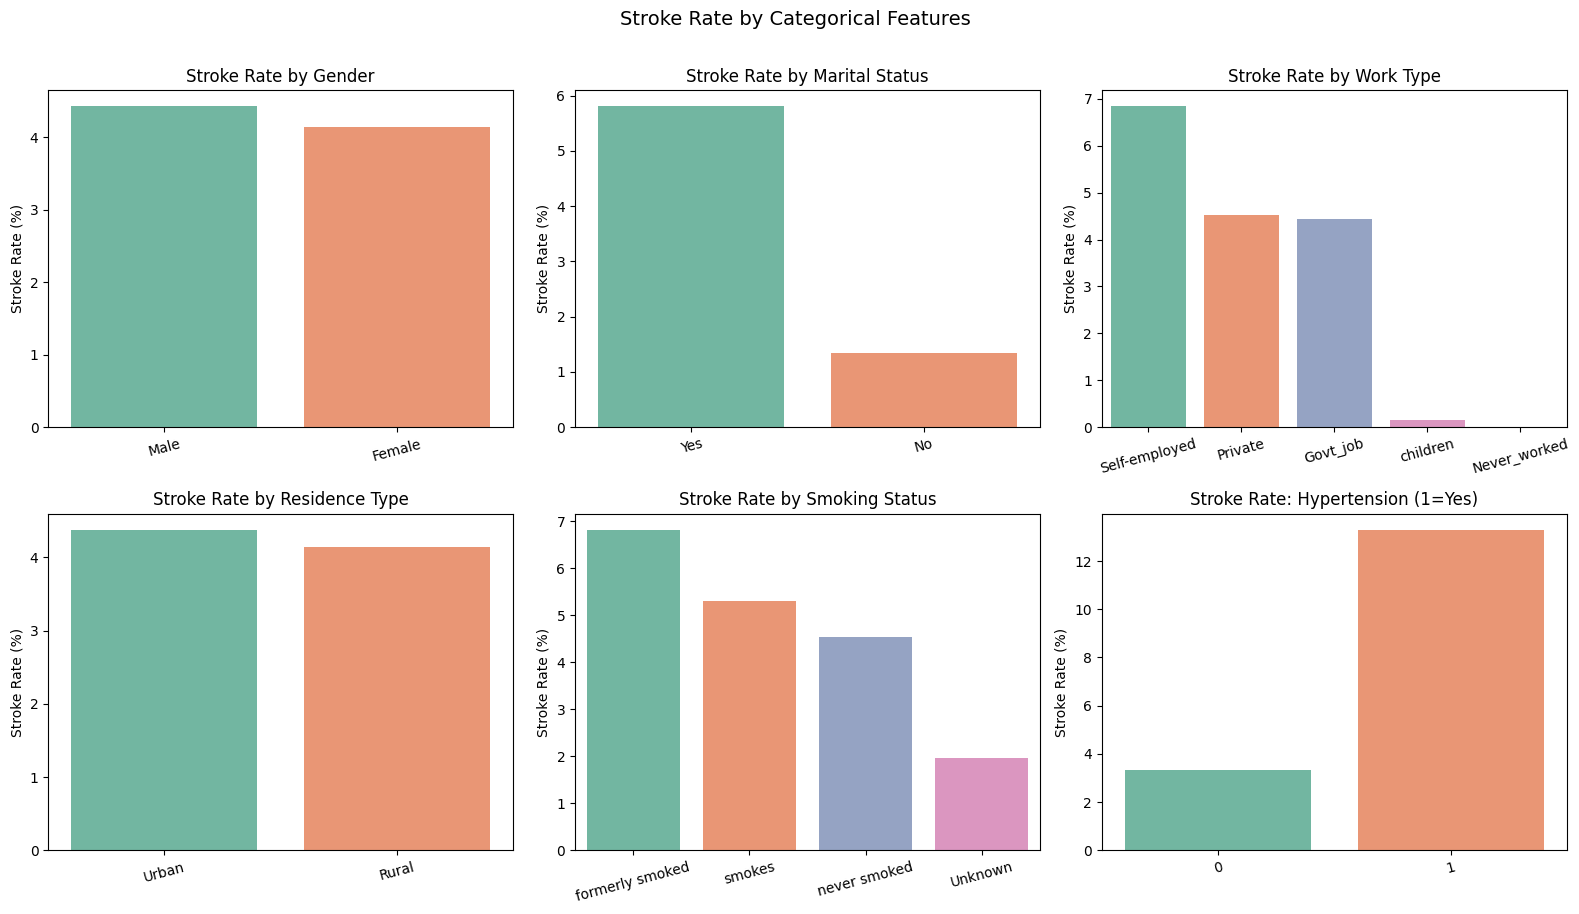

In [8]:
# helper function to plot stroke rate for a given categorical column
def plot_stroke_rate(column, title, ax):
    data = df.groupby(column)['stroke'].mean().reset_index()
    data['stroke_pct'] = data['stroke'] * 100
    data = data.sort_values('stroke_pct', ascending=False)
    sns.barplot(data=data, x=column, y='stroke_pct', palette='Set2', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Stroke Rate (%)')
    ax.tick_params(axis='x', rotation=15)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_stroke_rate('gender', 'Stroke Rate by Gender', axes[0, 0])
plot_stroke_rate('ever_married', 'Stroke Rate by Marital Status', axes[0, 1])
plot_stroke_rate('work_type', 'Stroke Rate by Work Type', axes[0, 2])
plot_stroke_rate('Residence_type', 'Stroke Rate by Residence Type', axes[1, 0])
plot_stroke_rate('smoking_status', 'Stroke Rate by Smoking Status', axes[1, 1])
plot_stroke_rate('hypertension', 'Stroke Rate: Hypertension (1=Yes)', axes[1, 2])

plt.suptitle('Stroke Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Key observations:
# - Gender: Males have a slightly higher stroke rate than females but the difference is small.

# - Marital status: Married patients show much higher stroke rates but this likely
#   because older people are more likely to have been married.

# - Work type: Self-employed patients show the highest stroke rate. Again, likely because
#   self employment is more common in older age brackets.

# - Residence type: Nearly identical rates. Where the person lives doesn't seem to matter much.

# - Smoking: 'formerly smoked' shows the highest stroke rate, slightly above current smokers.
#   people may quit after a health event.

# - Hypertension: Patients with hypertension have roughly double the stroke rate of those without.

#### 6. BMI and glucose level distributions by stroke outcome


C:\Users\savin\AppData\Local\Temp\ipykernel_73468\1699956948.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\savin\AppData\Local\Temp\ipykernel_73468\1699956948.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


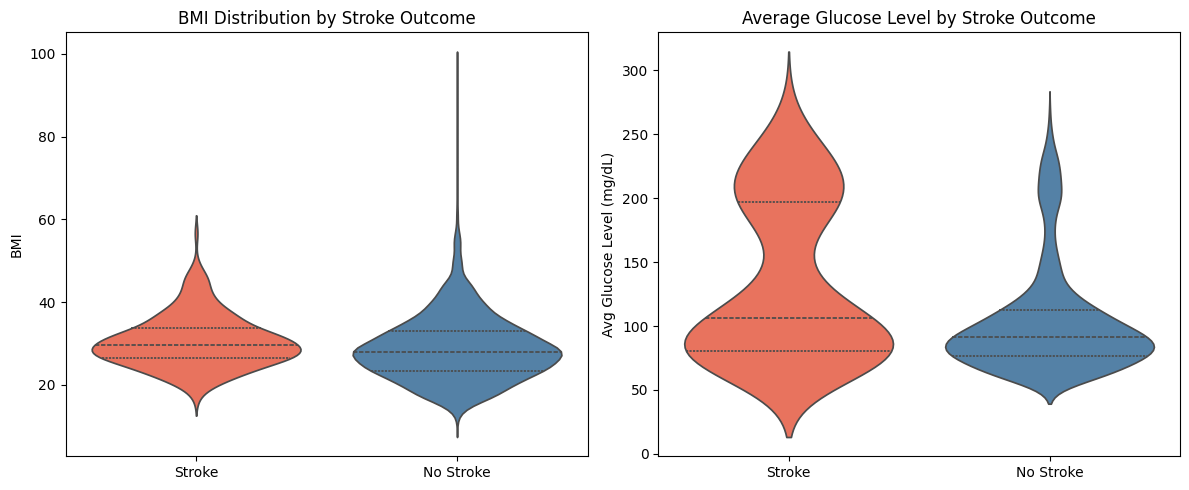

In [9]:
df['stroke_label'] = df['stroke'].map({0: 'No Stroke', 1: 'Stroke'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(
    data=df, x='stroke_label', y='bmi',
    palette={'No Stroke': 'steelblue', 'Stroke': 'tomato'},
    ax=axes[0], inner='quartile'
)
axes[0].set_title('BMI Distribution by Stroke Outcome')
axes[0].set_xlabel('')
axes[0].set_ylabel('BMI')

sns.violinplot(
    data=df, x='stroke_label', y='avg_glucose_level',
    palette={'No Stroke': 'steelblue', 'Stroke': 'tomato'},
    ax=axes[1], inner='quartile'
)
axes[1].set_title('Average Glucose Level by Stroke Outcome')
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg Glucose Level (mg/dL)')

plt.tight_layout()
plt.show()

# BMI: The distributions are largely overlapping. Stroke patients do not show
# a dramatically different BMI profile. The difference is modest.
#
# Glucose: Stroke patients show a noticeably wider spread and
# a heavier upper tail in glucose levels. High glucose is a known
# diabetes indicator and diabetes is a well documented stroke risk factor.
# This second peak visible in the stroke group around 200+ mg/dL suggests
# a subset of diabetic patients within the stroke group.

<h3><b>Results and summary:</b></h3>

- The analysis explored both demographic patterns and key risk factors for stroke in a dataset of ~4,900 cleaned patient records.

- The most important finding is that **age is by far the strongest predictor of stroke** in this dataset. Patients aged 71–82 had a stroke rate of around 16%, compared to near-zero for patients under 40. This rise accelerates sharply after age 50.

- **Hypertension** stood out among the medical indicators. patients with hypertension had approximately double the stroke rate of those without.

- **Elevated glucose levels** appear relevant for a subset of stroke patients. The distribution shows a secondary peak at high glucose values among those who had strokes. This is a known risk factor. 

- **BMI** showed only a weak difference between stroke and non stroke patients. It is a less discriminating factor on its own.

- Several categorical patterns (marital status, work type) that appeared to correlate with stroke rate are likely because older patients are more likely to be married and self employed. These should not be interpreted as independent risk factors without controlling for age.

- **Smoking** shows a pattern where former smokers have a higher stroke rate than current smoker. a known effect of reverse causality (quitting after a health event).


<h3><b>Ideas for further improvements:</b></h3>

- **Control for age** in categorical comparisons using age stratified analysis or conditional plots. this would separate true effects from the age confounding visible in the work type and marital status results.

- **Address the class imbalance.**

- **Resolve the Unknown smoking status.** if additional data were available to classify the 1,544 "Unknown" smoking records, the smoking analysis could be present with more confidence.

